<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week03/linear_neuron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear neuron

##1. LSQ Algorithm and Gradient descent algorithm



### Implementation of the model and its training algorithms
- and the SSE (The Sum squared error), SAE (The Sum absolute error), MSE (The Mean squared error), MAE (The Mean absolute error) functions


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time

class LinearNeuron:
    def __init__(self, input_dim, init_method='zero'):
        # weight initialization:
        if init_method == 'random':
            self.weights = np.random.uniform(-1, 1, (input_dim, 1)) / 10  # Random initialization
            self.bias = float(np.random.uniform(-1, 1) / 10)
        elif init_method == 'widrow-hoff':
            self.weights = np.random.randn(input_dim, 1) * (2 / np.sqrt(input_dim))  # Widrow-Hoff rule
            self.bias = float(np.random.randn() * (2 / np.sqrt(input_dim)))
        else: # init_method == 'zero':
            self.weights = np.zeros((input_dim, 1))  # Initialize weights to zeros
            self.bias = 0.0
        self.epochs = -1

    def set_weights(self, weights, bias):
        self.weights = np.array(weights, dtype=float).reshape(-1, 1)
        self.bias = float(bias)

    def __str__(self):
        return f"LinearNeuron(weights={self.weights.T}, bias={self.bias})"

    def activation(self, x):
        return x

    def forward(self, inputs):
        potential = np.dot(inputs, self.weights) + self.bias
        #potential = inputs @ self.weights + self.bias
        return self.activation(potential).flatten()

    def LSQ_naive(self, training_inputs, true_outputs):
        X_aug = np.hstack([training_inputs, np.ones((training_inputs.shape[0], 1))]) # extend input matrix by ones

        weights_aug = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ true_outputs      # naive computation (fails for singular or ill-conditioned matrices)

        self.weights = weights_aug[:-1].reshape(-1, 1)  # Ensure column vector
        self.bias = float(weights_aug[-1].item())

    def LSQ_pseudoinverse(self, training_inputs, true_outputs):
        X_aug = np.hstack([training_inputs, np.ones((training_inputs.shape[0], 1))]) # extend input matrix by ones

        # weights_aug = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ true_outputs      # naive computation (fails for singular or ill-conditioned matrices)
        weights_aug = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ true_outputs       # Moore-Penrose pseudoinverse

        self.weights = weights_aug[:-1].reshape(-1, 1)  # Ensure column vector
        self.bias = float(weights_aug[-1].item())

    def LSQ_tichonov(self, training_inputs, true_outputs, lambda_reg=1e-5):
        X_aug = np.hstack([training_inputs, np.ones((training_inputs.shape[0], 1))]) # extend input matrix by ones

        n = X_aug.shape[1]

        # weights_aug = np.linalg.inv((X_aug.T @ X_aug) + np.eye(n) * lambda_reg) @ X_aug.T @ true_outputs # compute inverse explicitly (less stable and unnecessary)
        weights_aug = np.linalg.solve((X_aug.T @ X_aug) + np.eye(n) * lambda_reg, X_aug.T @ true_outputs) # use Gauss elimination with pivoting

        self.weights = weights_aug[:-1].reshape(-1, 1)  # Ensure column vector
        self.bias = float(weights_aug[-1].item())

    def LSQ(self, training_inputs, true_outputs):
        X_aug = np.hstack([training_inputs, np.ones((training_inputs.shape[0], 1))]) # extend input matrix by the first column of ones

        weights_aug, _, _, _ = np.linalg.lstsq(X_aug, true_outputs, rcond=None)  # using library function

        self.weights = weights_aug[:-1].reshape(-1, 1)  # ensure column vector
        self.bias = float(weights_aug[-1].item())

    def gradient_descent_iterative(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set = None,  print_progress=False):
        if print_progress:
            print("Gradient Descent iterative:")
        learning_rate_0 = learning_rate # initial learning rate
        training_errors = []
        validation_errors = []

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = MSE_error(validation_true_outputs.flatten(), self.forward(validation_inputs))

        for epoch in range(epochs):

            # Shuffle the training data for each epoch
            shuffled_indices = np.random.permutation(len(training_inputs))
            training_inputs = training_inputs[shuffled_indices]
            true_outputs = true_outputs[shuffled_indices]

            for inputs, true_output in zip(training_inputs, true_outputs):
                prediction = self.forward(inputs.T).reshape(-1, 1)  # Ensure row vector for forward pass
                error = true_output - prediction
                self.weights += learning_rate * error * inputs.reshape(-1, 1)  # Update weights
                self.bias += float((learning_rate * error).item())             # Update bias

            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch + 1)**0.5)

            # Validation:
            if validation_set:
                validation_mse = MSE_error(validation_true_outputs.flatten(), self.forward(validation_inputs))
                validation_errors.append(validation_mse)
                if validation_mse < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_mse

            mse = MSE_error(true_outputs.flatten(), self.forward(training_inputs))
            training_errors.append(mse)
            if print_progress:
                if validation_set:
                    print(f"Epoch: {epoch}, Training MSE: {mse:0.4f}, Validation MSE: {validation_mse:0.4f} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, MSE: {mse:0.4f} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")

            # Stop conditions:
            if (mse <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and validation_steps > max_validation_steps):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)
        self.epochs = epoch+1
        return training_errors, validation_errors


    def gradient_descent_batch(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set = None,  print_progress=False):
        if print_progress:
            print("Gradient Descent batch:")

        training_inputs = np.array(training_inputs)  # (m, n)
        true_outputs = np.array(true_outputs).reshape(-1, 1)  # (m, 1)
        batch_size = training_inputs.shape[0]  # Scalar

        learning_rate_0 = learning_rate # initial learning rate
        training_errors = []
        validation_errors = []

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = MSE_error(validation_true_outputs.flatten(), self.forward(validation_inputs))

        for epoch in range(epochs):
            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch + 1)**0.5)
            prediction = self.forward(training_inputs).reshape(-1, 1)  # (m, 1)
            errors = true_outputs - prediction  # (m, 1)
            weight_gradient = (training_inputs.T @ errors)   # (n, 1)
            bias_gradient = np.sum(errors)  # Scalar

            self.weights += learning_rate * weight_gradient  # (n, 1)
            self.bias += learning_rate * bias_gradient  # Scalar

            # Validation:
            if validation_set:
                validation_mse = MSE_error(validation_true_outputs.flatten(), self.forward(validation_inputs))
                validation_errors.append(validation_mse)
                if validation_mse < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_mse
            mse = MSE_error(true_outputs.flatten(), self.forward(training_inputs))  # (m,)
            training_errors.append(mse)

            if print_progress:
                if validation_set:
                    print(f"Epoch: {epoch}, Training MSE: {mse:0.4f}, Validation MSE: {validation_mse:0.4f} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, MSE: {mse:0.4f} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")

            # Stop conditions:
            if (mse <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and validation_steps > max_validation_steps):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)

        self.epochs = epoch + 1
        return training_errors, validation_errors

def sign(x):
    return np.where(x > 0, 1, np.where(x < 0, -1, 0))

def perceptron_error(true_outputs, predicted_outputs):
    return np.sum(true_outputs != predicted_outputs)

def SSE_error(true_outputs, predicted_outputs):
    # The Sum squared error
    return np.sum((true_outputs - predicted_outputs) ** 2)
def SAE_error(true_outputs, predicted_outputs):
    # The Sum absolute error
    return np.sum(np.abs(true_outputs - predicted_outputs))
def MAE_error(true_outputs, predicted_outputs):
    # The Mean absolute error
    return np.mean(np.abs(true_outputs - predicted_outputs))
def MSE_error(true_outputs, predicted_outputs):
    # The Mean squared error
    return np.mean((true_outputs - predicted_outputs) ** 2)

### Auxiliary functions:
- for plotting and runing examples

In [14]:

def plot_regression_3D(perceptron, training_inputs, true_outputs):
    """Plots the data points and the regression plane in 3D."""

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot of the data points
    ax.scatter(training_inputs[:, 0], training_inputs[:, 1], true_outputs.flatten(),
               label="Data points", color='blue', alpha=0.4, s=50)

    # Create a meshgrid for the plane
    x_range = np.linspace(min(training_inputs[:, 0]), max(training_inputs[:, 0]), 20)
    y_range = np.linspace(min(training_inputs[:, 1]), max(training_inputs[:, 1]), 20)
    X, Y = np.meshgrid(x_range, y_range)

    # Calculate Z values for the plane using the perceptron's weights and bias
    Z = perceptron.weights[0] * X + perceptron.weights[1] * Y + perceptron.bias

    # Plot the regression plane
    ax.plot_surface(X, Y, Z, alpha=0.5, facecolors=plt.cm.Reds(Z), edgecolor='k', rstride=1, cstride=1)

    # Labels
    ax.set_xlabel("x_1")
    ax.set_ylabel("x_2")
    ax.set_zlabel("y")
    ax.set_title("3D Linear Regression Fit")

    plt.show()

def plot_decision_boundary_2D(perceptron, training_inputs, true_outputs):
    """Plots the decision boundary of the perceptron."""
    import matplotlib.pyplot as plt
    import numpy as np

    # Extract the first two columns of training_inputs
    x1 = training_inputs[:, 0]
    x2 = training_inputs[:, 1]

    # Generate points for visualization
    x_min, x_max = np.min(x1) - 1, np.max(x1) + 1  # Extend the range slightly
    y_min, y_max = np.min(x2) - 1, np.max(x2) + 1  # Extend the range slightly

    x = np.linspace(x_min, x_max, 100)
    weights = perceptron.weights.flatten()
    y = -(weights[0] * x + perceptron.bias) / weights[1]

    plt.figure(figsize=(5, 3))
    # Plot the decision boundary
    plt.plot(x, y, label='Decision Boundary')

    # Plot the points
    for i, input_vector in enumerate(training_inputs):
        if true_outputs[i] == 1:
            plt.scatter(input_vector[0], input_vector[1], color='green', label='Class 1' if i == 0 else "")  # Add label only for the first point of each class
        else:
            plt.scatter(input_vector[0], input_vector[1], color='red', label='Class -1' if i == 0 else "")

    plt.xlabel('x1', fontsize=12)
    plt.ylabel('x2', fontsize=12)
    plt.title('Perceptron Decision Boundary', fontsize=14)
    plt.grid(True)
    plt.legend()
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)  # Set y-axis limits

    # Highlight x and y axes
    plt.axhline(0, color='black', linewidth=0.8)  # x-axis
    plt.axvline(0, color='black', linewidth=0.8)  # y-axis
    plt.show()

def plot_regression(perceptron, training_inputs, true_outputs):
    """Plots the data points and the regression line."""
    plt.figure(figsize=(4, 3))

    # Plot the data points
    plt.scatter(training_inputs, true_outputs, label="Data points", color='blue', alpha=0.6)

    # Generate predictions for the regression line
    X_test = np.linspace(-1, 1, 100).reshape(-1, 1)
    d_pred = perceptron.weights * X_test + perceptron.bias

    plt.plot(X_test, d_pred, label="Regression line", color='red', linewidth=2)
    plt.xlabel("x_1")
    plt.ylabel("y")
    plt.legend()
    plt.title("Linear Regression Fit")
    plt.show()

def plot_error_progress(train_errors, validation_errors=None):
    fig = plt.figure(figsize=(4, 3))
    if validation_errors:
        plt.plot(validation_errors, label='Validation Error')
    plt.plot(train_errors, label='Train Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.title('Validation and Train Error Progress')
    plt.legend()
    plt.grid(True)
    plt.show()

def run_example_LSQ(experiment_results, inputs, true_outputs, init_method, variant, data_description):
    times = []
    errors = []
    epoch_counts = []

    start_time = time.time()
    perceptron = LinearNeuron(inputs.shape[1], init_method)
    if variant == 'pseudoinverse':
        perceptron.LSQ_pseudoinverse(inputs, true_outputs)
    elif variant == 'tichonov':
        perceptron.LSQ_tichonov(inputs, true_outputs)
    elif variant == 'library':
        perceptron.LSQ(inputs, true_outputs)
    elif variant == 'gradient':
        perceptron.gradient_descent_iterative(inputs, true_outputs)
    elif variant == 'batch':
        perceptron.gradient_descent_batch(inputs, true_outputs)
    end_time = time.time()
    elapsed_time = end_time - start_time

    real_outputs = perceptron.forward(inputs)
    error_MSE = MSE_error(true_outputs, real_outputs)
    error_SSE = SSE_error(true_outputs, real_outputs)

    results = {
        'MSE': error_MSE,
        'SSE': error_SSE,
        'Time': elapsed_time,
        'Variant': variant,
        'Weights': perceptron.weights,
        'Bias': perceptron.bias,
        'Data Description': data_description
    }
    experiment_results.loc[len(experiment_results)] = results


def run_example_multiple_times(experiment_results, training_data, testing_data, validation_data, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=10, num_runs=10):
    inputs, true_outputs = training_data
    if testing_data is None:
        testing_data = training_data
    max_validation_steps = None if validation_data is None else max_validation_steps
    test_inputs, test_true_outputs = testing_data
    times = []
    mse_errors = []
    mae_errors = []
    mse_test_errors = []
    mae_test_errors = []
    epoch_counts = []

    for _ in range(num_runs):

        start_time = time.time()
        neuron = LinearNeuron(inputs.shape[1], init_method)

        if variant == 'iterative':
            neuron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress)
        elif variant == 'batch':
            neuron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress, print_progress=print_progress)
        elif variant == 'pseudoinverse':
            neuron.LSQ_pseudoinverse(inputs, true_outputs)
        elif variant == 'naive':
            neuron.LSQ_naive(inputs, true_outputs)
        elif variant == 'tichonov':
            neuron.LSQ_tichonov(inputs, true_outputs)
        else:
            neuron.LSQ(inputs, true_outputs)

        end_time = time.time()
        elapsed_time = end_time - start_time

        real_outputs = neuron.forward(inputs)
        mse = MSE_error(true_outputs, real_outputs)
        mae = MAE_error(true_outputs, real_outputs)

        real_outputs = neuron.forward(test_inputs)
        mse_test = MSE_error(test_true_outputs, real_outputs)
        mae_test = MAE_error(test_true_outputs, real_outputs)

        times.append(elapsed_time)
        mse_errors.append(mse)
        mae_errors.append(mae)
        mse_test_errors.append(mse_test)
        mae_test_errors.append(mae_test)
        epoch_counts.append(neuron.epochs)

    avg_time = np.mean(times)
    avg_mse = np.mean(mse_errors)
    avg_mae = np.mean(mae_errors)
    avg_test_mse = np.mean(mse_test_errors)
    avg_test_mae = np.mean(mae_test_errors)
    avg_epochs = np.mean(epoch_counts)

    results = {
        'Epochs': avg_epochs,
        'MSE': avg_mse,
        'MAE': avg_mae,
        'Test MSE': avg_test_mse,
        'Test MAE': avg_test_mae,
        'Time': avg_time,
        'Variant': variant,
        'Learning Rate': learning_rate,
        'Max Epochs': epochs,
        'Weights': neuron.weights,  # Note: Weights and bias are from the last run.
        'Bias': neuron.bias,
        'Data Description': data_description
    } #experiment_results_r = pd.DataFrame(columns=['MSE', 'SSE', 'Test MSE' 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

    experiment_results.loc[len(experiment_results)] = results

### Example 1
- train the linear neuron on the given data:
- you can change the training data and the variant of LSQ:
- observe carefully the predicted values and errors ... is the linear neuron model good for tasks with binary/bipolar outputs?

LinearNeuron(weights=[[-0.5 -0.5]], bias=0.5)
LSQ: naive
Perceptron error: 4
SSE error: 1.0
MSE error: 0.25
SAE error: 2.0
MAE error: 0.5


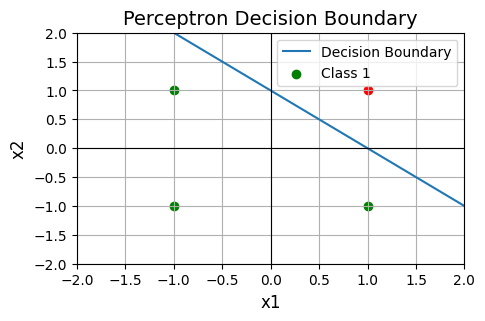

,Input,Predicted,True
0,"[-1, -1]",[1.5],1
1,"[-1, 1]",[0.5],1
2,"[1, -1]",[0.5],1
3,"[1, 1]",[-0.5],-1


In [15]:
# Example 1 from the presentation:
# Data:
inputs = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
true_outputs = np.array([1, 1, 1, -1])
#variant = "tichonov"
#variant = "pseudoinverse"
#variant = "library"
variant = "naive"

# Linear Neuron parameters:
init_method = 'random'

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
if variant == "library":
    perceptron.LSQ(inputs, true_outputs)
elif variant == "pseudoinverse":
    perceptron.LSQ_pseudoinverse(inputs, true_outputs)
elif variant == "tichonov":
    perceptron.LSQ_tichonov(inputs, true_outputs)
elif variant == "naive":
    perceptron.LSQ_naive(inputs, true_outputs)

# Print summary:
print(perceptron)
print("LSQ:", variant)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
print(f"Perceptron error: {perceptron_error(true_outputs, real_outputs)}")
print(f"SSE error: {SSE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
print(f"SAE error: {SAE_error(true_outputs, real_outputs)}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}

df


- comparison of LSQ variants:

In [16]:
# Example 1
# Data and parameters:
inputs = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
true_outputs = np.array([1, 1, 1, -1])
data_description = "Ex. 1"
init_method = 'zero'

# Run experiment:
experiment_results_1 = pd.DataFrame(columns=['MSE', 'SSE', 'Time', 'Variant', 'Weights', 'Bias', 'Data Description'])
for variant in ['naive', 'library', 'pseudoinverse', 'tichonov', 'gradient', 'batch']:
    run_example_LSQ(experiment_results_1, inputs, true_outputs, init_method, variant, data_description)
print("\nExperiment Results:")
experiment_results_1


Experiment Results:


,MSE,SSE,Time,Variant,Weights,Bias,Data Description
0,1.000000,4.000000,0.000010,naive,"[[0.0], [0.0]]",0.000000,Ex. 1
1,0.250000,1.000000,0.000183,library,"[[-0.5], [-0.49999999999999994]]",0.500000,Ex. 1
2,0.250000,1.000000,0.000262,pseudoinverse,"[[-0.5], [-0.5]]",0.500000,Ex. 1
3,0.250000,1.000000,0.000138,tichonov,"[[-0.49999875000312505], [-0.49999875000312505]]",0.499999,Ex. 1
4,0.251021,1.004085,0.027459,gradient,"[[-0.4765362512926808], [-0.5161845773614475]]",0.485549,Ex. 1
5,0.250000,1.000000,0.003925,batch,"[[-0.49999999999999994], [-0.5]]",0.500000,Ex. 1


### Example 2
- train the linear neuron on the given data:
- you can change the training data ant the variant of LSQ:

LinearNeuron(weights=[[ 0. -1.]], bias=0.0)
LSQ: pseudoinverse
Perceptron error: 0
SSE error: 0.0
MSE error: 0.0
SAE error: 0.0
MAE error: 0.0


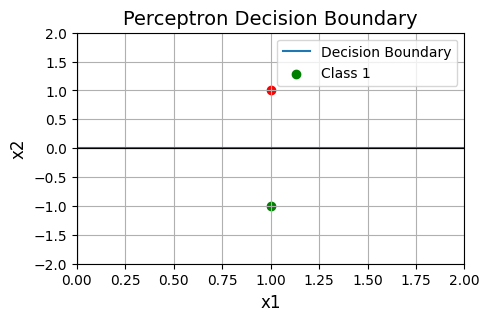

,Input,Predicted,True
0,"[1, -1]",[1.0],1
1,"[1, 1]",[-1.0],-1


In [20]:
# Example 2 from the presentation:
# Data:
inputs = np.array([[1, -1], [1, 1]])
true_outputs = np.array([1, -1])
#variant = "library"
variant = "pseudoinverse"
#variant = "tichonov"
# variant = "naive"

# Linear Neuron parameters:
init_method = 'random'

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
if variant == "library":
    perceptron.LSQ(inputs, true_outputs)
elif variant == "pseudoinverse":
    perceptron.LSQ_pseudoinverse(inputs, true_outputs)
elif variant == "tichonov":
    perceptron.LSQ_tichonov(inputs, true_outputs)

# Print summary:
print(perceptron)
print("LSQ:", variant)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
print(f"Perceptron error: {perceptron_error(true_outputs, real_outputs)}")
print(f"SSE error: {SSE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
print(f"SAE error: {SAE_error(true_outputs, real_outputs)}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}

df


-comparison of LSQ variants:

In [21]:
# Example 2 from the presentation:
# Data and parameters:
inputs = np.array([[1, -1], [1, 1]])
true_outputs = np.array([1, -1])
data_description = "Ex. 2"
init_method = 'zero'

# Run experiment:
experiment_results_1 = pd.DataFrame(columns=['MSE', 'SSE', 'Time', 'Variant', 'Weights', 'Bias', 'Data Description'])
for variant in ['naive', 'pseudoinverse', 'tichonov', 'library', 'gradient', 'batch']:
    run_example_LSQ(experiment_results_1, inputs, true_outputs, init_method, variant, data_description)
print("\nExperiment Results:")
experiment_results_1 #.round(5)




Experiment Results:


,MSE,SSE,Time,Variant,Weights,Bias,Data Description
0,1.000000e+00,2.000000e+00,0.000014,naive,"[[0.0], [0.0]]",0.000000e+00,Ex. 2
1,0.000000e+00,0.000000e+00,0.000417,pseudoinverse,"[[0.0], [-1.0]]",0.000000e+00,Ex. 2
2,2.499975e-11,4.999950e-11,0.000283,tichonov,"[[0.0], [-0.9999950000249999]]",0.000000e+00,Ex. 2
3,3.204747e-31,6.409495e-31,0.001504,library,"[[-3.3306690738754696e-16], [-1.00000000000000...",-2.775558e-16,Ex. 2
4,1.972152e-31,3.944305e-31,0.030316,gradient,"[[4.963944145858686e-17], [-1.0000000000000004]]",4.963944e-17,Ex. 2
5,0.000000e+00,0.000000e+00,0.002607,batch,"[[0.0], [-1.0]]",0.000000e+00,Ex. 2


### Example: XOR

LinearNeuron(weights=[[ 0.00000000e+00 -2.22044605e-16]], bias=0.0)
LSQ: library
Perceptron error: 4
SSE error: 4.0
MSE error: 1.0
SAE error: 4.0
MAE error: 1.0


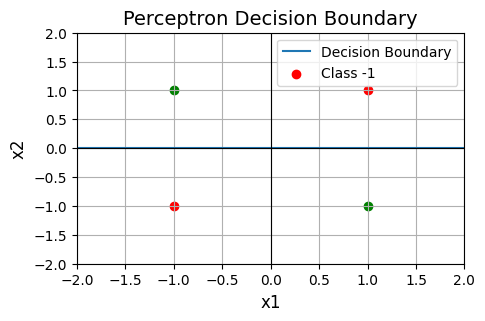

,Input,Predicted,True
0,"[-1, -1]",[2.220446049250313e-16],-1
1,"[-1, 1]",[-2.220446049250313e-16],1
2,"[1, -1]",[2.220446049250313e-16],1
3,"[1, 1]",[-2.220446049250313e-16],-1


In [23]:
# Example XOR:
# Data:
inputs = np.array([ [-1, -1],
                    [-1,  1],
                    [ 1, -1],
                    [ 1,  1]])
true_outputs = np.array([-1, 1, 1, -1])
variant = "library"
#variant = "pseudoinverse"
#variant = "tichonov"

# Linear Neuron parameters:
init_method = 'random'

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
if variant == "library":
    perceptron.LSQ(inputs, true_outputs)
elif variant == "pseudoinverse":
    perceptron.LSQ_pseudoinverse(inputs, true_outputs)
elif variant == "tichonov":
    perceptron.LSQ_tichonov(inputs, true_outputs)

# Print summary:
print(perceptron)
print("LSQ:", variant)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
print(f"Perceptron error: {perceptron_error(true_outputs, real_outputs)}")
print(f"SSE error: {SSE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
print(f"SAE error: {SAE_error(true_outputs, real_outputs)}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}

df

### Example 3: Linear regression


- create the data:

In [24]:
def generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=100):
    # y = A x1 + B + noise

    # Define true function with noise
    inputs = np.random.uniform(-1, 1, size=(number_of_samples, 1))  # Random values between -1 and 1
    noise = np.random.normal(0, std_noise, size=inputs.shape)  # Gaussian noise

    true_outputs = A * inputs[:, [0]]  + B + noise
    return inputs, true_outputs.flatten()

inputs, true_outputs = generate_regression_data_1D()

- train the linear neuron on the data
- you can change the true outputs and the level of additive noise in the data


LinearNeuron(weights=[[1.47670986]], bias=3.0062792356640813)
LSQ: pseudoinverse
Perceptron error: 100
MSE error: 0.09824207457410013
MAE error: 0.25290902884278776


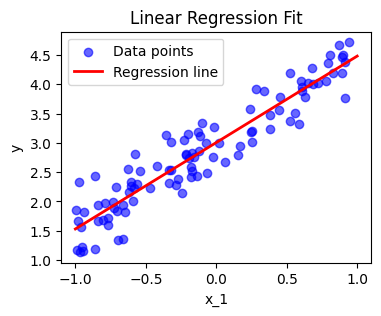

,Input,Predicted,True
0,[-0.9890684230886064],[1.5457121394255937],1.173171
1,[0.5249174848514464],[3.7814300631671487],3.368566
2,[-0.7689904107133709],[1.8707035110812222],1.600722
3,[-0.12853480245884197],[2.816470625045764],3.190242
4,[-0.3193316926268628],[2.534718975373419],3.012868
...,...,...,...
95,[-0.2139180324830976],[2.6903843670753003],2.817479
96,[-0.6940324976082433],[1.9813946007251237],1.344816
97,[-0.6498193611307654],[2.0466845754660525],1.812488
98,[0.3846686203933234],[3.5743231816506262],3.472529


In [31]:
# Example: simple linear regression
# Data and parameters:
inputs, true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=100)

#variant = "library"
variant = "pseudoinverse"
#variant = "tichonov"
#variant = "naive"

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1])
if variant == "library":
    perceptron.LSQ(inputs, true_outputs)
elif variant == "pseudoinverse":
    perceptron.LSQ_pseudoinverse(inputs, true_outputs)
elif variant == "tichonov":
    perceptron.LSQ_tichonov(inputs, true_outputs)
elif variant == "naive":
    perceptron.LSQ_naive(inputs, true_outputs)

# Print summary:
print(perceptron)
print("LSQ:", variant)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
print(f"Perceptron error: {perceptron_error(true_outputs, real_outputs)}")
#print(f"SSE error: {SSE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
#print(f"SAE error: {SAE_error(true_outputs, real_outputs)}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
plot_regression(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}

df

- comparison of LSQ variants:

In [32]:

# Data and parameters:
inputs, true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=100)
data_description = "Lin. regr. 1"
init_method = 'random'

# Run experiment:
experiment_results_1 = pd.DataFrame(columns=['MSE', 'SSE', 'Time', 'Variant', 'Weights', 'Bias', 'Data Description'])
for variant in ['library', 'pseudoinverse', 'tichonov', 'gradient', 'batch']:
    run_example_LSQ(experiment_results_1, inputs, true_outputs, init_method, variant, data_description)
print("\nExperiment Results:")
experiment_results_1


Experiment Results:


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,MSE,SSE,Time,Variant,Weights,Bias,Data Description
0,9.285451e-02,9.285451e+00,0.000262,library,[[1.5028537825834902]],2.989992e+00,Lin. regr. 1
1,9.285451e-02,9.285451e+00,0.000324,pseudoinverse,[[1.5028537825834907]],2.989992e+00,Lin. regr. 1
2,9.285451e-02,9.285451e+00,0.000180,tichonov,[[1.5028532322423391]],2.989991e+00,Lin. regr. 1
3,1.037071e-01,1.037071e+01,0.175354,gradient,[[1.4835051149650567]],3.091786e+00,Lin. regr. 1
4,1.120751e+238,1.120751e+240,0.003513,batch,[[1.423743229965693e+118]],-1.042320e+119,Lin. regr. 1


- observe how the level of noise in the data affects the training and error

In [35]:
# Data and parameters
data_description = "Lin. regr. 1"
init_method = 'zero'
variant = 'pseudoinverse'

# Run experiment:
experiment_results_1 = pd.DataFrame(columns=['MSE', 'SSE', 'Time', 'Variant', 'Weights', 'Bias', 'Data Description'])
for std_noise in [0.01, 0.1, 1, 10]:
    np.random.seed(42)
    inputs, true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=std_noise, number_of_samples=100)
    run_example_LSQ(experiment_results_1, inputs, true_outputs, init_method, variant, data_description + " Noise:" + str(std_noise) )
print("\nExperiment Results:")
experiment_results_1 #.round(5)


Experiment Results:


,MSE,SSE,Time,Variant,Weights,Bias,Data Description
0,0.000081,0.008066,0.000384,pseudoinverse,[[1.4977011338643844]],2.999852,Lin. regr. 1 Noise:0.01
1,0.008066,0.806585,0.000273,pseudoinverse,[[1.4770113386438481]],2.998521,Lin. regr. 1 Noise:0.1
2,0.806585,80.658456,0.002424,pseudoinverse,[[1.2701133864384833]],2.985210,Lin. regr. 1 Noise:1
3,80.658456,8065.845640,0.000314,pseudoinverse,[[-0.7988661356151623]],2.852095,Lin. regr. 1 Noise:10


### Example 4 - Linear regression with two input dimensions

- create and observe the data:

In [36]:
def generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.3, number_of_samples=100):
    # y = A x1 + B x2 + C + noise

    # Generate x1 and x2 from a uniform distribution (more variation than linspace)
    x1 = np.random.uniform(-1, 1, number_of_samples).reshape(-1, 1)
    x2 = np.random.uniform(-1, 1, number_of_samples).reshape(-1, 1)
    x2 = x2[np.random.permutation(number_of_samples)]  # Randomly shuffle x2
    inputs = np.hstack([x1, x2])

    # Define true function with noise
    noise = np.random.normal(0, std_noise, size=x1.shape)  # Gaussian noise
    true_outputs = A*x1 + B*x2 + C + noise
    return inputs, true_outputs.flatten()

inputs, true_outputs = generate_regression_data_2D()

- train the linear neuron on the data
- you can change the true outputs and the level of additive noise in the data





LinearNeuron(weights=[[1.93785071 2.87484252]], bias=-4.008667717827274)
LSQ: tichonov
Perceptron error: 100
MSE error: 0.09845030745013669
MAE error: 0.2627986425681245


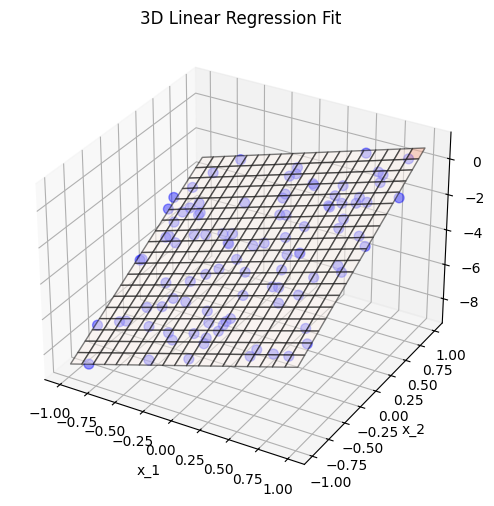

(100, 2)


,Input,Predicted,True
0,"[0.8480835182148663, -0.8453578690224255]",[-4.795479214005596],-5.037077
1,"[-0.5277669337651913, 0.2675171274403545]",[-4.262331634237717],-4.534189
2,"[0.5199108178751712, 0.5571438781015021]",[-1.399457256599335],-1.789680
3,"[0.06253150794706808, -0.6689589792654205]",[-5.810642709254933],-5.352408
4,"[0.4410321227829297, 0.5048062400776454]",[-1.702774859502321],-1.975967
...,...,...,...
95,"[-0.1829634141281662, -0.7955746715496008]",[-6.650375395450659],-6.369273
96,"[0.8658761341999093, -0.6273582410117586]",[-4.13428518011817],-4.228631
97,"[0.9818589529147812, 0.06371495937634797]",[-1.9228011700270038],-1.804642
98,"[-0.5899963798935255, 0.9181495891280556]",[-2.5124571441034504],-2.301773


In [37]:
# Define parameters
inputs, true_outputs = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.3, number_of_samples=100)
variant = "tichonov"
init_method = 'random'

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
if variant == "library":
    perceptron.LSQ(inputs, true_outputs)
elif variant == "pseudoinverse":
    perceptron.LSQ_pseudoinverse(inputs, true_outputs)
elif variant == "tichonov":
    perceptron.LSQ_tichonov(inputs, true_outputs)

# Print summary:
print(perceptron)
print("LSQ:", variant)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
print(f"Perceptron error: {perceptron_error(true_outputs, real_outputs)}")
#print(f"SSE error: {SSE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
#print(f"SAE error: {SAE_error(true_outputs, real_outputs)}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
plot_regression_3D(perceptron, inputs, true_outputs)
print(np.shape(inputs))

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}

df


- comparison of LSQ variants:



In [38]:
# Data and parameters:
inputs, true_outputs = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.5, number_of_samples=100)
data_description = "Lin. regr. 2"
init_method = 'random'

# Run experiment:
experiment_results_1 = pd.DataFrame(columns=['MSE', 'SSE', 'Time', 'Variant', 'Weights', 'Bias', 'Data Description'])
for variant in ['library', 'pseudoinverse', 'tichonov', 'gradient', 'batch']:
    run_example_LSQ(experiment_results_1, inputs, true_outputs, init_method, variant, data_description)
print("\nExperiment Results:")
experiment_results_1


Experiment Results:


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,MSE,SSE,Time,Variant,Weights,Bias,Data Description
0,2.271642e-01,2.271642e+01,0.000291,library,"[[1.7500526876853206], [2.800876408245493]]",-3.941388e+00,Lin. regr. 2
1,2.271642e-01,2.271642e+01,0.000383,pseudoinverse,"[[1.7500526876853235], [2.800876408245494]]",-3.941388e+00,Lin. regr. 2
2,2.271642e-01,2.271642e+01,0.000241,tichonov,"[[1.7500519111577966], [2.8008753460979166]]",-3.941387e+00,Lin. regr. 2
3,2.288824e-01,2.288824e+01,0.215426,gradient,"[[1.818106108632567], [2.8221090503830584]]",-3.935740e+00,Lin. regr. 2
4,4.510363e+238,4.510363e+240,0.005321,batch,"[[1.1695889556163824e+118], [3.106930916978376...",2.078753e+119,Lin. regr. 2


- observe how the level of noise in the data affects the training and error

In [40]:
# Data and parameters
inputs, true_outputs = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=2.5, number_of_samples=100)
data_description = "Lin. regr. 2"
init_method = 'zero'
variant = 'pseudoinverse'

# Run experiment:
experiment_results_1 = pd.DataFrame(columns=['MSE', 'SSE', 'Time', 'Variant', 'Weights', 'Bias', 'Data Description'])
for std_noise in [0.01, 0.1, 1, 2]:
    np.random.seed(42)
    inputs, true_outputs = generate_regression_data_2D(A=2, B=3, C = -4, std_noise=std_noise, number_of_samples=100)
    run_example_LSQ(experiment_results_1, inputs, true_outputs, init_method, variant, data_description + " Noise:" + str(std_noise) )
print("\nExperiment Results:")
experiment_results_1 #.round(5)


Experiment Results:


,MSE,SSE,Time,Variant,Weights,Bias,Data Description
0,0.000104,0.010415,0.000326,pseudoinverse,"[[2.0033162865773786], [2.995430899968277]]",-3.999275,Lin. regr. 2 Noise:0.01
1,0.010415,1.041477,0.000193,pseudoinverse,"[[2.0331628657738046], [2.954308999682752]]",-3.992748,Lin. regr. 2 Noise:0.1
2,1.041477,104.147656,0.000172,pseudoinverse,"[[2.3316286577380607], [2.543089996827503]]",-3.927485,Lin. regr. 2 Noise:1
3,4.165906,416.590623,0.000165,pseudoinverse,"[[2.6632573154761228], [2.0861799936550036]]",-3.854970,Lin. regr. 2 Noise:2


##2. Iterative and batch gradient descent algorithm:


### Example 1
- In this example, we train the linear neuron a classification task
- Observe the training process, does the algorithm converge?
- Are the predicted outputs close to the expected ones?
- Experiment with the learning rate and other training parameters (maximum number of epochs, adaptive learning rate) and observe, how it affects the training process
- Try to initialize weights with large values and observe, how it affects training

Gradient Descent iterative:
Epoch: 0, MSE: 0.8326 Weights: [[-0.08422412  0.01607861]] Bias: 0.12135673587217784 Learning rate: 0.0300
Epoch: 1, MSE: 0.7024 Weights: [[-0.13246142 -0.04561085]] Bias: 0.167047707965599 Learning rate: 0.0300
Epoch: 2, MSE: 0.6021 Weights: [[-0.17535075 -0.10026523]] Bias: 0.20517836506400064 Learning rate: 0.0300
Epoch: 3, MSE: 0.5235 Weights: [[-0.2142668  -0.14660205]] Bias: 0.24130394261374566 Learning rate: 0.0300
Epoch: 4, MSE: 0.4623 Weights: [[-0.24943168 -0.18746144]] Bias: 0.2724083761075829 Learning rate: 0.0300
Epoch: 5, MSE: 0.4137 Weights: [[-0.2784764  -0.22664871]] Bias: 0.30021959350385097 Learning rate: 0.0300
Epoch: 6, MSE: 0.3784 Weights: [[-0.30229398 -0.25931809]] Bias: 0.3228941504354638 Learning rate: 0.0300
Epoch: 7, MSE: 0.3496 Weights: [[-0.32474478 -0.28810354]] Bias: 0.3452539965733207 Learning rate: 0.0300
Epoch: 8, MSE: 0.3276 Weights: [[-0.34386815 -0.31408666]] Bias: 0.3632664792245274 Learning rate: 0.0300
Epoch: 9, MSE: 

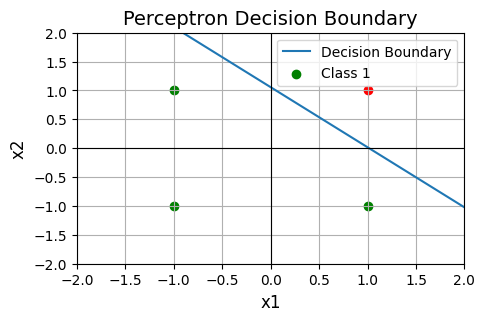

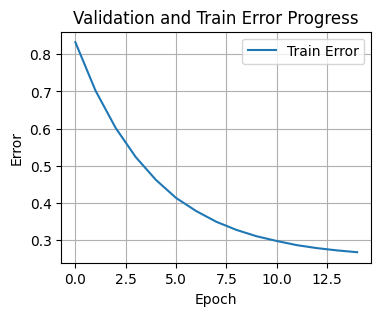

,Input,Predicted,True
0,"[-1, -1]",[1.2722854915984214],1
1,"[-1, 1]",[0.4506987950236194],1
2,"[1, -1]",[0.41773270004513785],1
3,"[1, 1]",[-0.40385399652966414],-1


In [ ]:
# Example 1 from the presentation:
# Data and parameters:
inputs = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
true_outputs = np.array([1, 1, 1, -1])

print_progress = True
learning_rate = 0.03
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 15

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
# perceptron.set_weights(np.array([10000, 10000]), 10000) # set weights to large values
training_errors, validation_errors = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress=print_progress)
# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
error = perceptron_error(true_outputs, real_outputs)
print(f"Perceptron error: {error}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)
plot_error_progress(training_errors, validation_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


- finetune parameters of the algorithm:
    1. number of epochs
    2. learning rate
    3. adaptive learning rate or not?

In [ ]:
# DataFrame to store the results for comparisons:
experiment_results_r = pd.DataFrame(columns=['MSE', 'MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])
#np.random.seed(42)  # For reproducibility
inputs = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
true_outputs = np.array([1, 1, 1, -1])
data_description_orig = "Ex. 1"
variant = "iterative"

# Perceptron parameters:
adaptive_learning_rate = False

min_error = 0.0001
epochs = 100
learning_rate = 0.1
init_method = 'random'
print_progress = False
data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)

# learning rate:
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# epochs:
learning_rate = 0.1
for epochs in [2, 5, 10, 20]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# adaptive learning rate:
adaptive_learning_rate = True
data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)
epochs = 100
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

print("\nExperiment Results:")
experiment_results_r


Experiment Results:


,MSE,MAE,Epochs,Time,Variant,Learning Rate,Max Epochs,Weights,Bias,Data Description
0,2.502310e-01,5.000000e-01,100.0,0.040753,iterative,0.01,100,"[[-0.4914438080609323], [-0.4928691337005592]]",4.922753e-01,Ex. 1 non-adaptive 0.0001
1,2.507029e-01,5.000000e-01,100.0,0.037239,iterative,0.10,100,"[[-0.5044684573658201], [-0.4863291413602032]]",5.088929e-01,Ex. 1 non-adaptive 0.0001
2,7.568523e+105,3.342420e+52,100.0,0.041973,iterative,1.00,100,"[[2.072439993745895e+50], [-3.774598422272479e...",1.537802e+50,Ex. 1 non-adaptive 0.0001
3,3.670229e-01,5.429055e-01,2.0,0.000820,iterative,0.10,2,"[[-0.36994477350775534], [-0.2636916534758979]]",2.933846e-01,Ex. 1 non-adaptive 0.0001
4,2.567116e-01,5.000000e-01,5.0,0.003540,iterative,0.10,5,"[[-0.4370315031127268], [-0.446818666825944]]",4.508118e-01,Ex. 1 non-adaptive 0.0001
5,2.512454e-01,5.000000e-01,10.0,0.004722,iterative,0.10,10,"[[-0.4718692426991517], [-0.528370482477878]]",5.065036e-01,Ex. 1 non-adaptive 0.0001
6,2.509732e-01,5.000000e-01,20.0,0.010275,iterative,0.10,20,"[[-0.5074034749450996], [-0.5180181888351312]]",4.904714e-01,Ex. 1 non-adaptive 0.0001
7,4.080386e-01,5.910423e-01,100.0,0.045403,iterative,0.01,100,"[[-0.23579659857630297], [-0.29921556165012886]]",2.819399e-01,Ex. 1 adaptive 0.0001
8,2.500008e-01,5.000000e-01,100.0,0.040310,iterative,0.10,100,"[[-0.4986927990583558], [-0.5002511918564787]]",4.999571e-01,Ex. 1 adaptive 0.0001
9,2.510050e-01,5.000000e-01,100.0,0.048196,iterative,1.00,100,"[[-0.48571944036702425], [-0.5123574027259935]]",4.717367e-01,Ex. 1 adaptive 0.0001


### Example 2
- In this example, we train the linear neuron a task with a low number of training patterns
- Observe the training process, does the algorithm converge?
- Are the predicted outputs close to the expected ones?
- Experiment with the learning rate and other training parameters (maximum number of epochs, adaptive learning rate) and observe, how it affects the training process


Gradient Descent iterative:
Epoch: 0, MSE: 0.6991 Weights: [[ 0.01951021 -0.168001  ]] Bias: 0.06364442201723336 Learning rate: 0.1000
Epoch: 1, MSE: 0.4343 Weights: [[-0.00460916 -0.34188924]] Bias: 0.03952505198724286 Learning rate: 0.1000
Epoch: 2, MSE: 0.2707 Weights: [[-0.01782429 -0.47974334]] Bias: 0.026309925012846222 Learning rate: 0.1000
Epoch: 3, MSE: 0.1691 Weights: [[-0.01423399 -0.5890821 ]] Bias: 0.02990022046542922 Learning rate: 0.1000
Epoch: 4, MSE: 0.1055 Weights: [[-0.02131975 -0.67521819]] Bias: 0.02281445802103576 Learning rate: 0.1000
Epoch: 5, MSE: 0.0659 Weights: [[-0.01835593 -0.74343732]] Bias: 0.025778282408348313 Learning rate: 0.1000
Epoch: 6, MSE: 0.0411 Weights: [[-0.01720055 -0.79738971]] Bias: 0.026933662264741715 Learning rate: 0.1000
Epoch: 7, MSE: 0.0257 Weights: [[-0.01702374 -0.8400352 ]] Bias: 0.02711047391247328 Learning rate: 0.1000
Epoch: 8, MSE: 0.0160 Weights: [[-0.02053987 -0.87352694]] Bias: 0.023594346188467057 Learning rate: 0.1000
Epoch

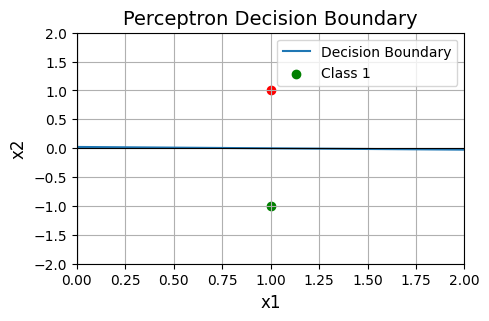

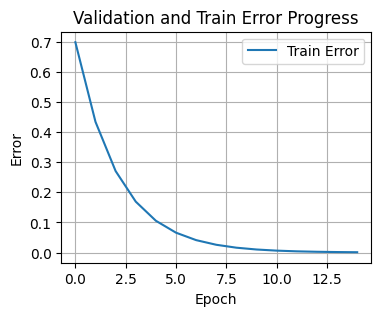

,Input,Predicted,True
0,"[1, -1]",[0.9678656741473416],1
1,"[1, 1]",[-0.9706317163791615],-1


In [ ]:
# Example 2 from the presentation:
# Data:
inputs = np.array([[1, -1], [1, 1]])
true_outputs = np.array([1, -1])
print_progress = True
learning_rate = 0.1
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 15

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
training_errors, validation_errors = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress=print_progress)

# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
error = perceptron_error(true_outputs, real_outputs)
print(f"Perceptron error: {error}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)
plot_error_progress(training_errors, validation_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}

df


- finetune parameters of the algorithm:
    1. number of epochs
    2. learning rate
    3. adaptive learning rate or not?

In [ ]:
# DataFrame to store the results for comparisons:
experiment_results_r = pd.DataFrame(columns=['MSE', 'MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])
#np.random.seed(42)  # For reproducibility
inputs = np.array([[1, -1], [1, 1]])
true_outputs = np.array([1, -1])
data_description_orig = "Ex. 2"
variant = "iterative"

# Perceptron parameters:
adaptive_learning_rate = False
min_error = 0.0001
epochs = 100
learning_rate = 0.1
init_method = 'random'
print_progress = False

data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)

# learning rate:
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# epochs:
learning_rate = 0.1
for epochs in [2, 5, 10, 20]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# adaptive learning rate:
adaptive_learning_rate = True
data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)
epochs = 100
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

print("\nExperiment Results:")
experiment_results_r


Experiment Results:


,MSE,MAE,Epochs,Time,Variant,Learning Rate,Max Epochs,Weights,Bias,Data Description
0,1.733746e-02,1.314574e-01,100.0,0.029390,iterative,0.01,100,"[[0.06915764137911287], [-0.8804961190139159]]",-6.999771e-02,Ex. 2 non-adaptive 0.0001
1,7.982200e-05,8.906242e-03,20.0,0.002315,iterative,0.10,100,"[[-0.0022058097118118868], [-0.990269064919442]]",1.859726e-03,Ex. 2 non-adaptive 0.0001
2,1.201497e+68,6.546095e+33,100.0,0.020500,iterative,1.00,100,"[[1.3275590774850954e+33], [2.7407766447394654...",1.327559e+33,Ex. 2 non-adaptive 0.0001
3,3.669013e-01,6.035142e-01,2.0,0.000586,iterative,0.10,2,"[[-0.005924547490116408], [-0.35291231663577005]]",1.535300e-02,Ex. 2 non-adaptive 0.0001
4,9.930132e-02,3.142685e-01,5.0,0.002689,iterative,0.10,5,"[[0.06097700561093495], [-0.7137233272958518]]",-5.965324e-02,Ex. 2 non-adaptive 0.0001
5,8.379417e-03,9.134193e-02,10.0,0.001502,iterative,0.10,10,"[[-0.001632574556282143], [-0.9116623677858919]]",6.995464e-03,Ex. 2 non-adaptive 0.0001
6,7.578476e-05,8.689288e-03,20.0,0.003531,iterative,0.10,20,"[[0.05399822731988206], [-0.9913960174150389]]",-5.340091e-02,Ex. 2 non-adaptive 0.0001
7,4.532631e-01,6.711764e-01,100.0,0.018702,iterative,0.01,100,"[[-0.05976628591352674], [-0.31914486500471434]]",6.461661e-02,Ex. 2 adaptive 0.0001
8,2.718055e-04,1.645797e-02,100.0,0.021512,iterative,0.10,100,"[[-0.08558421194557062], [-0.9828319482925522]]",8.562042e-02,Ex. 2 adaptive 0.0001
9,4.851467e-05,4.716498e-03,9.1,0.001230,iterative,1.00,100,"[[0.003783847749465716], [-0.9932264565710254]]",2.266178e-03,Ex. 2 adaptive 0.0001


### Example 3: linear regression
- In this example, we work with data for one-dimensional linear regression
- We work with three independent datasets:
    - training
    - validation - used for early stopping (and to monitor the model performance during the training)
    - testing - used just for final testing (whether the model generalizes well)
- Observe the training process of the iterative training algorithm, does the algorithm converge? Is the neuron function close to the true function? Observe, how the progress of the errors during training
- Compare the error on the training data and on the testing data
- Experiment with the noise levels and with the training parameters (learning rate, maximum number of epochs, weight initialization, adaptive learning rate,...) and observe, how it affects the training process
- Train the model with early stopping (by setting the parameter max_validation_steps to an integer value)

Gradient Descent iterative:
Epoch: 0, Training MSE: 0.4117, Validation MSE: 0.3485 Weights: [[0.78928422]] Bias: 2.6906556967099178 Learning rate: 0.0500
Epoch: 1, Training MSE: 0.1879, Validation MSE: 0.1150 Weights: [[1.22213782]] Bias: 2.976364240403609 Learning rate: 0.0500
Epoch: 2, Training MSE: 0.1606, Validation MSE: 0.1023 Weights: [[1.4309872]] Bias: 2.9516360587422312 Learning rate: 0.0500
Epoch: 3, Training MSE: 0.1568, Validation MSE: 0.1026 Weights: [[1.50828516]] Bias: 2.9615358559878007 Learning rate: 0.0500
Epoch: 4, Training MSE: 0.1598, Validation MSE: 0.1058 Weights: [[1.50890376]] Bias: 2.931494628767706 Learning rate: 0.0500
Epoch: 5, Training MSE: 0.1568, Validation MSE: 0.1039 Weights: [[1.53105912]] Bias: 2.95952176359829 Learning rate: 0.0500
Epoch: 6, Training MSE: 0.1555, Validation MSE: 0.1024 Weights: [[1.5315026]] Bias: 2.9978664398466623 Learning rate: 0.0500
Epoch: 7, Training MSE: 0.1555, Validation MSE: 0.1019 Weights: [[1.52279634]] Bias: 2.994614314

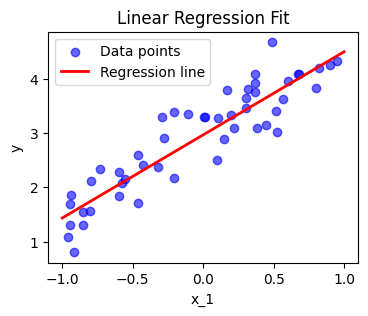

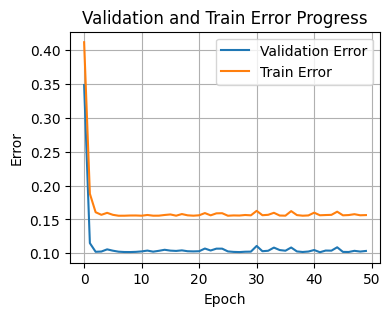

,Input,Predicted,True
0,[0.012992192408202818],[2.9851431503009533],3.285670
1,[-0.27806117270291963],[2.5393123177126147],2.907992
2,[0.5669371028766315],[3.8336669959122975],3.632110
3,[0.9494738882032314],[4.4196306504905944],4.334270
4,[0.16904303087638617],[3.224179298238347],3.790704
5,[-0.10792534466494219],[2.799923624640188],3.357424
6,[-0.5544517194635656],[2.115941752885786],2.145346
7,[0.30686683849560037],[3.4352955754128423],3.641234
8,[0.37115372363079424],[3.5337691852726416],3.763911
9,[0.3703812140287275],[3.5325858675709534],4.082865


In [ ]:
# Example: linear regression
# Training, validation and test data:
inputs, true_outputs           = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)  # y = A x1 + B + noise
test_inputs, test_true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)
validation_data                = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)

# Parameters:
print_progress = True
learning_rate = 0.05
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 50
max_validation_steps = None # None # no early stopping

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
#perceptron.set_weights(np.array([10000]), 10000) # set weights to large values
[training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)

# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)

print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_regression(perceptron, inputs, true_outputs)
plot_error_progress(training_errors, validation_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


#### Example 3 and the batch variant of gradient descent
- observe the training progress, compare it to the iterative variant
- experiment with the learning rate and with the number of epochs

Gradient Descent batch:
Epoch: 0, Training MSE: 2.9256, Validation MSE: 2.3652 Weights: [[0.35066421]] Bias: 1.5894062454667433 Learning rate: 0.0100
Epoch: 1, Training MSE: 0.9477, Validation MSE: 0.6851 Weights: [[0.64367943]] Bias: 2.3423190492466937 Learning rate: 0.0100
Epoch: 2, Training MSE: 0.4018, Validation MSE: 0.2752 Weights: [[0.85182556]] Bias: 2.707827279091899 Learning rate: 0.0100
Epoch: 3, Training MSE: 0.2281, Validation MSE: 0.1678 Weights: [[1.00601097]] Bias: 2.882804256719752 Learning rate: 0.0100
Epoch: 4, Training MSE: 0.1593, Validation MSE: 0.1335 Weights: [[1.12380319]] Bias: 2.96453178784702 Learning rate: 0.0100
Epoch: 5, Training MSE: 0.1253, Validation MSE: 0.1187 Weights: [[1.21573332]] Bias: 3.0009943843265714 Learning rate: 0.0100
Epoch: 6, Training MSE: 0.1057, Validation MSE: 0.1105 Weights: [[1.28850036]] Bias: 3.0157908208238045 Learning rate: 0.0100
Epoch: 7, Training MSE: 0.0935, Validation MSE: 0.1054 Weights: [[1.34662446]] Bias: 3.02047018339

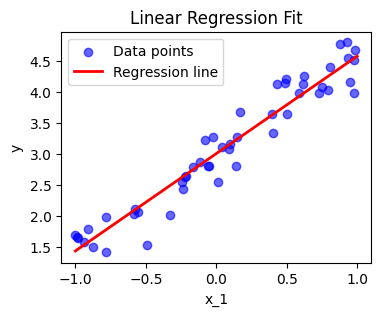

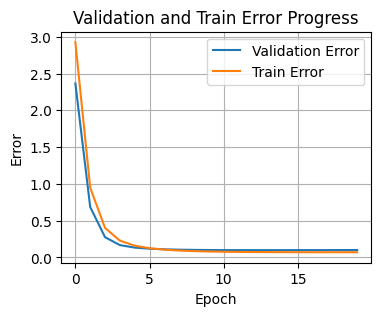

,Input,Predicted,True
0,[0.9296462509444956],[4.46590411278901],4.802285
1,[0.1433646521985421],[3.2301960307295885],2.805184
2,[0.87557526091758],[4.380926975478689],4.766135
3,[-0.9848171676521718],[1.457162813310409],1.637409
4,[0.14534116638224193],[3.233302290058305],3.266217
5,[0.4343737794505429],[3.68754150475809],4.135996
6,[0.49016034232443606],[3.7752148100008074],4.138646
7,[0.8099537635633627],[4.277797238286852],4.410330
8,[-0.9911967819924274],[1.4471367094142358],1.655170
9,[-0.9993396814810471],[1.4343394536657441],1.685909


In [ ]:
# Training, validation and test data:
inputs, true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)
test_inputs, test_true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)
validation_data                = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)

# Parameters:
print_progress = True
learning_rate = 0.01
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 20
max_validation_steps = None # no early stopping

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
[training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)

# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_regression(perceptron, inputs, true_outputs)
plot_error_progress(training_errors, validation_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


#### Finetuning - iterative algorithm
- finetune parameters of the iterative / batch algoritm:
    1. learning rate
    2. number of epochs
    3. ...

In [ ]:
# DataFrame to store the results for comparisons:
experiment_results_r = pd.DataFrame(columns=['MSE', 'MAE', 'Test MSE', 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])
#np.random.seed(42)  # For reproducibility
inputs, true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)
test_inputs, test_true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)
validation_data                = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)

data_description_orig = "regr. 1"

# Perceptron parameters:
variant = "iterative" # "batch"
adaptive_learning_rate = False
min_error = 0.0001
epochs = 100
learning_rate = 0.1
init_method = 'random'
print_progress = False
max_validation_steps = 5 #None

data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)

# learning rate
for learning_rate in [0.001, 0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), (test_inputs, test_outputs), validation_data, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps)

# epochs
learning_rate = 0.01
for epochs in [1, 2, 5, 10, 20]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), (test_inputs, test_outputs), validation_data, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps)

# adaptive learning rate:
adaptive_learning_rate = True
data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)
epochs = 100
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)


print("\nExperiment Results:")
experiment_results_r


Experiment Results:


,MSE,MAE,Test MSE,Test MAE,Epochs,Time,Variant,Learning Rate,Max Epochs,Weights,Bias,Data Description
0,0.140120,0.298901,1.178452,0.861214,100.0,0.114578,iterative,0.001,100,[[1.0167433684179685]],2.929875,regr. 1 non-adaptive 0.0001
1,0.098955,0.274014,1.369518,0.911483,99.2,0.058937,iterative,0.010,100,[[1.3778745966780017]],3.000924,regr. 1 non-adaptive 0.0001
2,0.101776,0.279045,1.409767,0.929625,100.0,0.055838,iterative,0.100,100,[[1.3309354493823324]],2.940532,regr. 1 non-adaptive 0.0001
3,0.347314,0.475037,1.843635,1.073745,100.0,0.063302,iterative,1.000,100,[[1.1780953627679214]],2.340303,regr. 1 non-adaptive 0.0001
4,3.659375,1.733553,4.897254,2.027969,1.0,0.000620,iterative,0.010,1,[[0.11093989770080188]],1.106120,regr. 1 non-adaptive 0.0001
5,1.644315,1.103299,2.666497,1.391198,2.0,0.001177,iterative,0.010,2,[[0.2945951716751053]],1.853807,regr. 1 non-adaptive 0.0001
6,0.351649,0.489918,1.218482,0.884870,5.0,0.002825,iterative,0.010,5,[[0.6734741955172624]],2.668356,regr. 1 non-adaptive 0.0001
7,0.137482,0.296392,1.183770,0.862584,10.0,0.005510,iterative,0.010,10,[[1.0492326963446699]],2.934798,regr. 1 non-adaptive 0.0001
8,0.100360,0.272293,1.328531,0.900248,20.0,0.011059,iterative,0.010,20,[[1.3085457796880033]],2.990748,regr. 1 non-adaptive 0.0001
9,0.100661,0.272194,0.100661,0.272194,100.0,0.057757,iterative,0.010,100,[[1.3059475324996783]],2.990640,regr. 1 adaptive 0.0001


#### Finetuning - batch algorithm
- comprate the iterative and batch algorithms:
    1. learning rate
    2. error and training time

In [ ]:
# DataFrame to store the results for comparisons:
experiment_results_r = pd.DataFrame(columns=['MSE', 'MAE', 'Test MSE', 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])
#np.random.seed(42)  # For reproducibility
inputs, true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)
test_inputs, test_true_outputs = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)
validation_data                = generate_regression_data_1D(A=1.5, B=3, std_noise=0.3, number_of_samples=50)

data_description_orig = "regr. 1"

# Perceptron parameters:
variant =  "batch"
adaptive_learning_rate = False
min_error = 0.0001
epochs = 50
learning_rate = 0.05
init_method = 'random'
print_progress = False
max_validation_steps = 5 #None

data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)

# learning rate
#for learning_rate in [0.001, 0.01, 0.1]:
#    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), (test_inputs, test_outputs), validation_data, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps)

# epochs
learning_rate = 0.01
for epochs in [1, 2, 5, 10, 20]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), (test_inputs, test_outputs), validation_data, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps)

# adaptive learning rate:
adaptive_learning_rate = True
data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)
epochs = 100
for learning_rate in [0.01, 0.05 , 0.1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)


print("\nExperiment Results:")
experiment_results_r


Experiment Results:


,MSE,MAE,Test MSE,Test MAE,Epochs,Time,Variant,Learning Rate,Max Epochs,Weights,Bias,Data Description
0,2.578617,1.416686,3.866999,1.756280,1.0,0.000085,batch,0.01,1,[[-0.02517344495647747]],1.345072,regr. 1 non-adaptive 0.0001
1,1.021689,0.789234,1.860150,1.108794,2.0,0.000099,batch,0.01,2,[[0.15041299810627662]],2.116734,regr. 1 non-adaptive 0.0001
2,0.313118,0.419057,0.963298,0.764367,5.0,0.000205,batch,0.01,5,[[0.5317847078631355]],2.735330,regr. 1 non-adaptive 0.0001
3,0.152531,0.304937,1.049691,0.831309,10.0,0.000339,batch,0.01,10,[[0.9817507313862859]],2.864179,regr. 1 non-adaptive 0.0001
4,0.105954,0.264229,1.244908,0.906129,20.0,0.000646,batch,0.01,20,[[1.3076702754340748]],2.903937,regr. 1 non-adaptive 0.0001
5,0.108949,0.267414,0.108949,0.267414,100.0,0.003056,batch,0.01,100,[[1.2567400129937982]],2.897997,regr. 1 adaptive 0.0001
6,0.102710,0.262464,0.102710,0.262464,100.0,0.003005,batch,0.05,100,[[1.420610701897751]],2.916888,regr. 1 adaptive 0.0001
7,0.102710,0.262464,0.102710,0.262464,100.0,0.003261,batch,0.10,100,[[1.4206139973959595]],2.916889,regr. 1 adaptive 0.0001


### Example 4 - Linear regression with two input dimensions


-   observe the training process of the iterative training algorithm, does the algorithm converge? Is the neuron function close to the true function?
-  compare the error on the training data and on the testing data
-  experiment with the noise levels and with the training parameters (learning rate, maximum number of epochs, weight initialization, adaptive learning rate,...) and observe, how it affects the training process


Gradient Descent iterative:
Epoch: 0, Training MSE: 0.3280, Validation MSE: 0.4125 Weights: [[1.70562304 2.38382785]] Bias: -4.0003449501579444 Learning rate: 0.0500
Epoch: 1, Training MSE: 0.2054, Validation MSE: 0.3028 Weights: [[1.92557341 2.85065654]] Bias: -4.026411345098427 Learning rate: 0.0354
Epoch: 2, Training MSE: 0.2025, Validation MSE: 0.3011 Weights: [[1.94290512 2.91490909]] Bias: -4.045803648460141 Learning rate: 0.0289
Epoch: 3, Training MSE: 0.2022, Validation MSE: 0.2995 Weights: [[1.96543513 2.90302519]] Bias: -4.02360835200827 Learning rate: 0.0250
Epoch: 4, Training MSE: 0.2017, Validation MSE: 0.2989 Weights: [[1.97661789 2.91823766]] Bias: -4.025826856947559 Learning rate: 0.0224
Epoch: 5, Training MSE: 0.2019, Validation MSE: 0.2983 Weights: [[1.99653613 2.94675289]] Bias: -4.054051996949271 Learning rate: 0.0204
Epoch: 6, Training MSE: 0.2015, Validation MSE: 0.2983 Weights: [[1.9944034  2.94382819]] Bias: -4.035965182379534 Learning rate: 0.0189
Epoch: 7, Tra

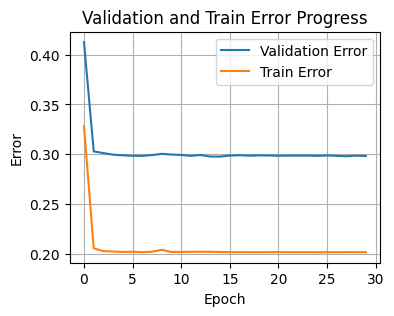

Train Perceptron error: 100, Test PE: 100
Train MAE error: 0.3628296984214343, Test MAE: 0.3596330584302435
Train MSE error: 0.2014527190863897, Test MSE: 0.1798571135537551


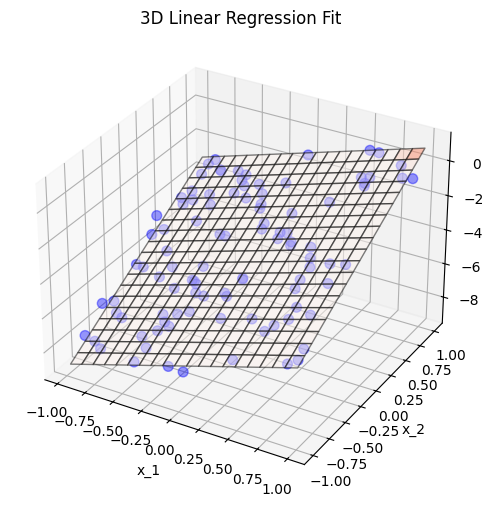

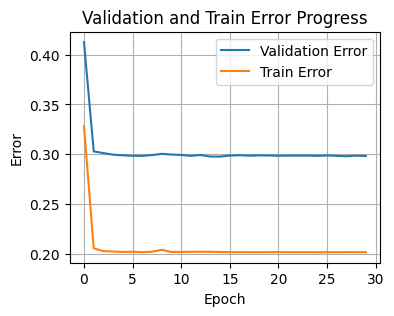

,Input,Predicted,True
0,"[-0.4479872774663898, 0.6051320583053328]",[-3.1442247240711607],-3.043998
1,"[-0.9589797137806473, -0.6623104069624834]",[-7.888335936266842],-8.637659
2,"[-0.4127729897880392, -0.36748020354381894]",[-5.931460003351225],-5.428788
3,"[0.2819704619209751, 0.20979387231739866]",[-2.8481627271511996],-3.296384
4,"[0.0270584697529328, 0.24351471211525166]",[-3.258095981758501],-2.814303
...,...,...,...
95,"[-0.3940504954328623, -0.5445986130659703]",[-6.414451917067777],-6.751548
96,"[-0.9542438095741619, 0.18696221498576482]",[-5.383702414539744],-5.110456
97,"[0.5860794394581619, -0.20289700017564916]",[-3.453413622376642],-3.522769
98,"[0.6696137564185323, -0.43311108796703124]",[-3.9629859325251955],-3.098872


In [ ]:
# Define parameters
inputs, true_outputs = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.5, number_of_samples=100)
test_inputs, test_true_outputs = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.5, number_of_samples=100)
validation_data = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.5, number_of_samples=100)

# Train the linear neuron:
print_progress = True
learning_rate = 0.05
init_method = 'random'
adaptive_learning_rate = True #False
min_error = 0.0001
epochs = 30
variant = "iterative"
max_validation_steps = None # no early stopping

# Train the linear neuron:
perceptron = LinearNeuron(inputs.shape[1], init_method)
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)

# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_regression_3D(perceptron, inputs, true_outputs)
plot_error_progress(training_errors, validation_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df

- finetune parameters of the iterative/batch method:

In [ ]:
# DataFrame to store the results for comparisons:
experiment_results_r = pd.DataFrame(columns=['MSE', 'MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])
#np.random.seed(42)  # For reproducibility
inputs, true_outputs = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.5, number_of_samples=100)
test_inputs, test_true_outputs = generate_regression_data_2D(A=2, B=3, C=-4, std_noise=0.5, number_of_samples=100)
data_description_orig = "regr. 2"
variant = "iterative"

# Perceptron parameters:
adaptive_learning_rate = False
min_error = 0.0001
epochs = 100
learning_rate = 0.1
init_method = 'random'
print_progress = False
max_validation_steps = None

data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)

for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), (test_inputs, test_outputs), validation_data, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps)
learning_rate = 0.1
for epochs in [1, 2, 5, 10, 20]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), (test_inputs, test_outputs), validation_data, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps)


print("\nExperiment Results:")
experiment_results_r


Experiment Results:


,MSE,MAE,Epochs,Time,Variant,Learning Rate,Max Epochs,Weights,Bias,Data Description
0,0.361484,0.479499,100.0,0.255388,iterative,0.01,100,"[[1.8968228753610707], [3.077798523918298]]",-4.038196,regr. 2 non-adaptive 0.0001
1,0.381911,0.490683,100.0,0.264848,iterative,0.10,100,"[[1.7447444873982816], [3.029905508707275]]",-4.088000,regr. 2 non-adaptive 0.0001
2,5.304742,1.790628,100.0,0.188853,iterative,1.00,100,"[[2.872462054681242], [4.102233960866636]]",-2.693945,regr. 2 non-adaptive 0.0001
3,0.402409,0.509098,1.0,0.001323,iterative,0.10,1,"[[1.744665948330264], [3.0697411720353496]]",-3.972137,regr. 2 non-adaptive 0.0001
4,0.376460,0.496050,2.0,0.002336,iterative,0.10,2,"[[1.8309092566252805], [3.2216559964807607]]",-4.002890,regr. 2 non-adaptive 0.0001
5,0.385780,0.494933,5.0,0.005139,iterative,0.10,5,"[[1.779959199375376], [3.126938254788309]]",-3.943683,regr. 2 non-adaptive 0.0001
6,0.392053,0.507003,10.0,0.010128,iterative,0.10,10,"[[2.103707222119581], [3.095781269502038]]",-3.984740,regr. 2 non-adaptive 0.0001
7,0.409078,0.510842,20.0,0.022510,iterative,0.10,20,"[[1.784761493979842], [2.9242902051693784]]",-3.824696,regr. 2 non-adaptive 0.0001
